<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/stochastic_minibatch_momentum_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

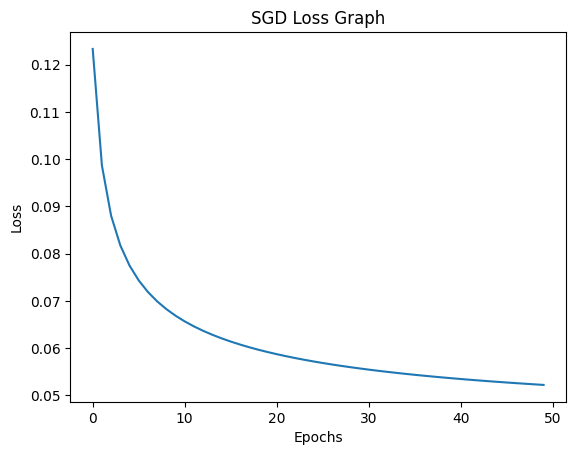

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target.reshape(-1,1)

# Normalize
X = StandardScaler().fit_transform(X)

# Initialize
w = np.zeros((X.shape[1],1))
b = 0
lr = 0.01
epochs = 50
losses = []

def sigmoid(z):
    return 1/(1+np.exp(-z))

for epoch in range(epochs):

    for i in range(len(X)):
        xi = X[i].reshape(1,-1)
        yi = y[i]

        z = np.dot(xi,w)+b
        y_pred = sigmoid(z)

        dw = xi.T*(y_pred-yi)
        db = y_pred-yi

        w -= lr*dw
        b -= lr*db

    pred = sigmoid(np.dot(X,w)+b)
    loss = -np.mean(y*np.log(pred)+(1-y)*np.log(1-pred))
    losses.append(loss)

plt.plot(losses)
plt.title("SGD Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

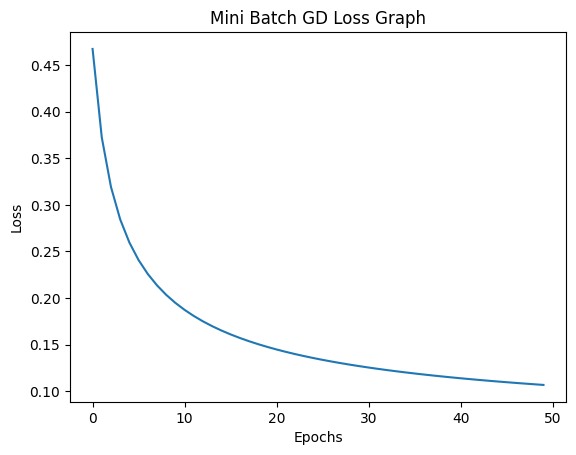

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
y = data.target.reshape(-1,1)

w = np.zeros((X.shape[1],1))
b = 0
lr = 0.01
epochs = 50
batch_size = 32
losses = []

def sigmoid(z):
    return 1/(1+np.exp(-z))

for epoch in range(epochs):

    for i in range(0,len(X),batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]

        z = np.dot(xb,w)+b
        y_pred = sigmoid(z)

        dw = np.dot(xb.T,(y_pred-yb))/len(xb)
        db = np.mean(y_pred-yb)

        w -= lr*dw
        b -= lr*db

    pred = sigmoid(np.dot(X,w)+b)
    loss = -np.mean(y*np.log(pred)+(1-y)*np.log(1-pred))
    losses.append(loss)

plt.plot(losses)
plt.title("Mini Batch GD Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

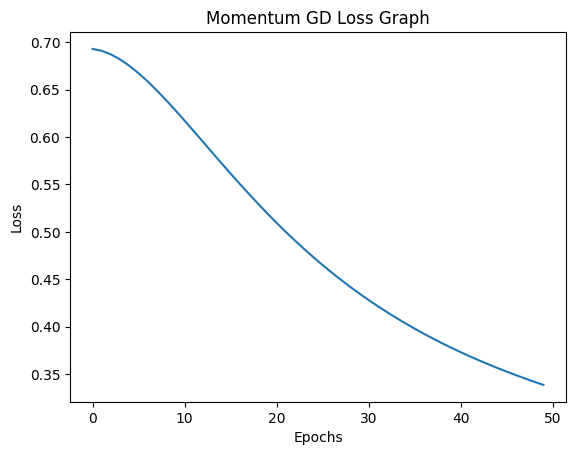

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
y = data.target.reshape(-1,1)

w = np.zeros((X.shape[1],1))
b = 0
lr = 0.01
beta = 0.9
epochs = 50

vdw = np.zeros_like(w)
vdb = 0
losses = []

def sigmoid(z):
    return 1/(1+np.exp(-z))

for epoch in range(epochs):

    z = np.dot(X,w)+b
    y_pred = sigmoid(z)

    dw = np.dot(X.T,(y_pred-y))/len(X)
    db = np.mean(y_pred-y)

    vdw = beta*vdw + (1-beta)*dw
    vdb = beta*vdb + (1-beta)*db

    w -= lr*vdw
    b -= lr*vdb

    loss = -np.mean(y*np.log(y_pred)+(1-y)*np.log(1-y_pred))
    losses.append(loss)

plt.plot(losses)
plt.title("Momentum GD Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()